SETUP & DATA LOADING

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
print(df.info())
print("Total Duplicates:", df.duplicated().sum())
print("Dataset Shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   str    
 1   patient_id             5000 non-null   str    
 2   gender                 5000 non-null   str    
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   str    
 5   appointment_type       5000 non-null   str    
 6   booking_date           5000 non-null   str    
 7   appointment_date       5000 non-null   str    
 8   appointment_day        5000 non-null   str    
 9   appointment_time       5000 non-null   str    
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   str    
 14  reminder_channel       3634 non-null   str    
 15  distance_to_cli

UNDESTANDING DATASET CONTENTS

In [ ]:
print("Appointment Outcomes:", df['appointment_outcome'].unique())
print("Genders:", df['gender'].unique())
print("Appointment Types:", df['appointment_type'].unique())
print("Reminder Sent:", df['reminder_sent'].unique())
print("Reminder Channels:", df['reminder_channel'].unique())
print("Age Groups:", df['age_group'].unique())
print("Appointment Days:", df['appointment_day'].unique())
print("Appointment Times:", df['appointment_time'].unique())

Appointment Outcomes: <StringArray>
['No-Show', 'Attended', 'Cancelled']
Length: 3, dtype: str
Genders: <StringArray>
['Female', 'Male', 'Prefer not to say']
Length: 3, dtype: str
Appointment Types: <StringArray>
[              'Follow-up', 'Specialist Consultation',
    'General Consultation',         'Diagnostic Test']
Length: 4, dtype: str
Reminder Sent: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Reminder Channels: <StringArray>
['WhatsApp', 'SMS', 'Email', nan]
Length: 4, dtype: str
Age Groups: <StringArray>
['35-44', '25-34', '45-54', '55-64', '65+', '18-24']
Length: 6, dtype: str
Appointment Days: <StringArray>
['Tuesday', 'Friday', 'Wednesday', 'Thursday', 'Monday', 'Sunday', 'Saturday']
Length: 7, dtype: str
Appointment Times: <StringArray>
['Afternoon', 'Morning', 'Evening']
Length: 3, dtype: str


In [3]:
print(df.isnull().sum())

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64


DATA PREPARATION    
1. Handling Missing Values


In [ ]:
df3 = df.distance_to_clinic_km.mean()
df.distance_to_clinic_km = df.distance_to_clinic_km.fillna(df3)
df['distance_to_clinic_km'] = df['distance_to_clinic_km'].astype(float).round(1)

waitingmean = df['waiting_time_minutes'].mean().round(1)
df['waiting_time_minutes'] = np.where(
    df['appointment_outcome'].isin(['No-Show', 'Cancelled']), 
    df['waiting_time_minutes'].fillna(0),                     
    df['waiting_time_minutes'].fillna(waitingmean)            
)

df.reminder_channel = df.reminder_channel.fillna('No Reminder')
df.isnull().sum()

appointment_id           0
patient_id               0
gender                   0
age                      0
age_group                0
appointment_type         0
booking_date             0
appointment_date         0
appointment_day          0
appointment_time         0
booking_lead_days        0
previous_appointments    0
previous_no_shows        0
reminder_sent            0
reminder_channel         0
distance_to_clinic_km    0
waiting_time_minutes     0
appointment_outcome      0
dtype: int64

2. Data Type Conversion & Feature Engineering

In [ ]:
#convert dates to correct datatype and validate booking lead days
df.booking_date = pd.to_datetime(df.booking_date)
df.appointment_date = pd.to_datetime(df.appointment_date)
df['booking_lead_days'] = df.appointment_date - df.booking_date
df['booking_lead_days'] = pd.to_numeric(df['booking_lead_days'].dt.days, errors='coerce')

df['distance_group'] = pd.cut(df['distance_to_clinic_km'], bins=[0, 10, 20, 30, 40, 50], 
                              labels=['<10km', '10-20km', '20-30km', '30-40km', '40km+'])

df.to_csv('cleaned_data.csv', index=False)


EXPLORATORY DATA ANALYSIS
1. Numerical Analysis

In [12]:
# 1. Age by Outcome
print("\n--- AGE ANALYSIS ---")
age_by_outcome = df.groupby('appointment_outcome')['age'].agg(['mean', 'median', 'count'])
print(age_by_outcome)

# 2. Distance by Outcome
print("\n--- DISTANCE ANALYSIS ---")
distance_by_outcome = df.groupby('appointment_outcome')['distance_to_clinic_km'].agg(['mean', 'median', 'std'])
print(distance_by_outcome)

# 3. Waiting Time by Outcome
print("\n--- WAITING TIME ANALYSIS ---")
waiting_by_outcome = df.groupby('appointment_outcome')['waiting_time_minutes'].agg(['mean', 'median', 'std'])
print(waiting_by_outcome)

# 4. Lead Time by Outcome
print("\n--- LEAD TIME ANALYSIS ---")
lead_by_outcome = df.groupby('appointment_outcome')['booking_lead_days'].agg(['mean', 'median', 'std'])
print(lead_by_outcome)

# 5. Previous No-Shows by Outcome
print("\n--- PREVIOUS NO-SHOW ANALYSIS ---")
prev_no_show_by_outcome = df.groupby('appointment_outcome')['previous_no_shows'].agg(['mean', 'median', 'std'])
print(prev_no_show_by_outcome)

# 6. Previous Appointments by Outcome
print("\n--- PREVIOUS APPOINTMENTS ANALYSIS ---")
prev_appt_by_outcome = df.groupby('appointment_outcome')['previous_appointments'].agg(['mean', 'median', 'std'])
print(prev_appt_by_outcome)


--- AGE ANALYSIS ---
                          mean  median  count
appointment_outcome                          
Attended             49.247623    50.0   2314
Cancelled            50.152091    50.0    263
No-Show              48.215023    48.0   2423

--- DISTANCE ANALYSIS ---
                          mean  median       std
appointment_outcome                             
Attended              9.675972     8.4  6.169413
Cancelled            10.111407     9.2  6.105018
No-Show              10.523112     9.3  6.876863

--- WAITING TIME ANALYSIS ---
                          mean  median        std
appointment_outcome                              
Attended             24.288332    24.0  10.896587
Cancelled            23.038023    22.0  10.709848
No-Show              23.831201    24.0  11.134935

--- LEAD TIME ANALYSIS ---
                          mean  median        std
appointment_outcome                              
Attended             24.521175    23.0  16.608868
Cancelled        

2. Categorical Analysis

In [13]:
# 1. Appointment Type vs Outcome (with percentages)
print("\n--- APPOINTMENT TYPE vs OUTCOME ---")
appt_type_cross = pd.crosstab(df['appointment_type'], df['appointment_outcome'], normalize='index') * 100
print(appt_type_cross.round(1))

# 2. Reminder Sent vs Outcome
print("\n--- REMINDER SENT vs OUTCOME ---")
reminder_cross = pd.crosstab(df['reminder_sent'], df['appointment_outcome'], normalize='index') * 100
print(reminder_cross.round(1))

# 3. Age Group vs Outcome
print("\n--- AGE GROUP vs OUTCOME ---")
age_group_cross = pd.crosstab(df['age_group'], df['appointment_outcome'], normalize='index') * 100
print(age_group_cross.round(1))

# 4. Gender vs Outcome
print("\n--- GENDER vs OUTCOME ---")
gender_cross = pd.crosstab(df['gender'], df['appointment_outcome'], normalize='index') * 100
print(gender_cross.round(1))

# 5. Appointment Day vs Outcome
print("\n--- APPOINTMENT DAY vs OUTCOME ---")
day_cross = pd.crosstab(df['appointment_day'], df['appointment_outcome'], normalize='index') * 100
print(day_cross.round(1))

# 6. Appointment Time vs Outcome
print("\n--- APPOINTMENT TIME vs OUTCOME ---")
time_cross = pd.crosstab(df['appointment_time'], df['appointment_outcome'], normalize='index') * 100
print(time_cross.round(1))


--- APPOINTMENT TYPE vs OUTCOME ---
appointment_outcome      Attended  Cancelled  No-Show
appointment_type                                     
Diagnostic Test              45.9        4.4     49.7
Follow-up                    43.3        5.4     51.2
General Consultation         48.3        5.1     46.6
Specialist Consultation      46.6        6.0     47.4

--- REMINDER SENT vs OUTCOME ---
appointment_outcome  Attended  Cancelled  No-Show
reminder_sent                                    
No                       42.7        5.9     51.4
Yes                      47.6        5.0     47.4

--- AGE GROUP vs OUTCOME ---
appointment_outcome  Attended  Cancelled  No-Show
age_group                                        
18-24                    45.6        4.3     50.2
25-34                    45.1        4.2     50.7
35-44                    45.7        6.0     48.4
45-54                    46.0        5.9     48.0
55-64                    45.0        4.2     50.7
65+                      

3. Correlation Analysis

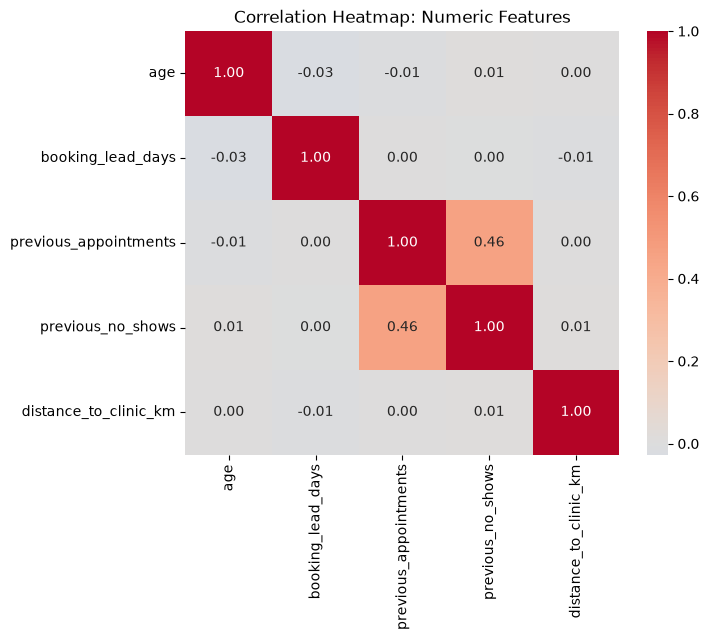

In [14]:
numeric_cols = ['age', 'booking_lead_days', 'previous_appointments', 
                'previous_no_shows', 'distance_to_clinic_km']
plt.figure(figsize=(7,5.5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Numeric Features')
plt.show()

VISUALIZATIONS
1. Demographic Analysis

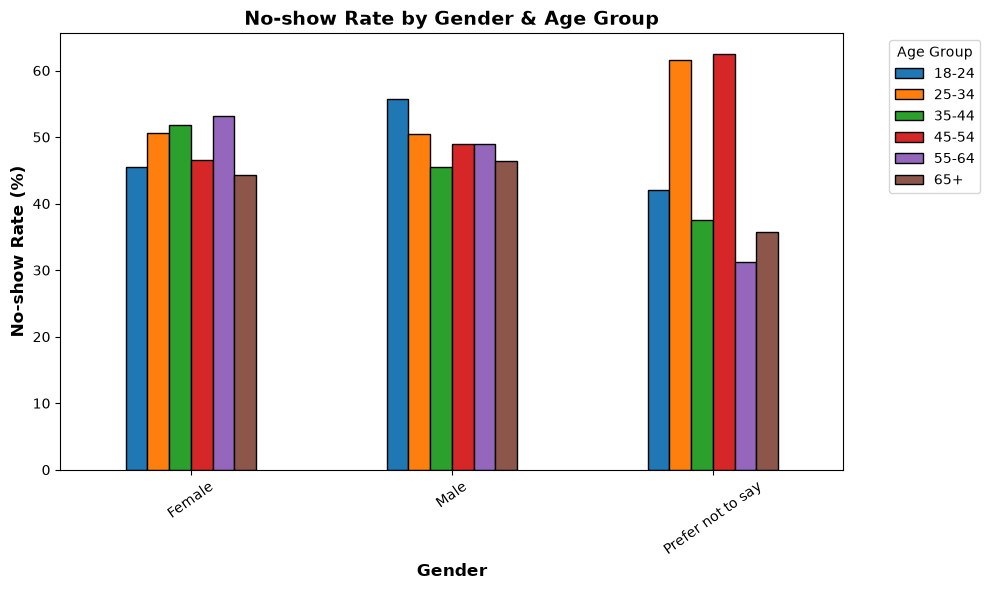

In [22]:
df['appointment_count'] = (df['appointment_outcome'] == 'No-Show').astype(int)
contract_payment_churn = df.groupby(['gender', 'age_group'])['appointment_count'].mean() * 100
contract_payment_churn = contract_payment_churn.unstack() 
contract_payment_churn.plot(kind='bar', figsize=(10,6), edgecolor='black')
plt.title('No-show Rate by Gender & Age Group', fontsize=14, weight='bold')
plt.xlabel('Gender', fontsize=12, fontweight='bold')
plt.ylabel('No-show Rate (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=35)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()

2. Appointment Details Analysis

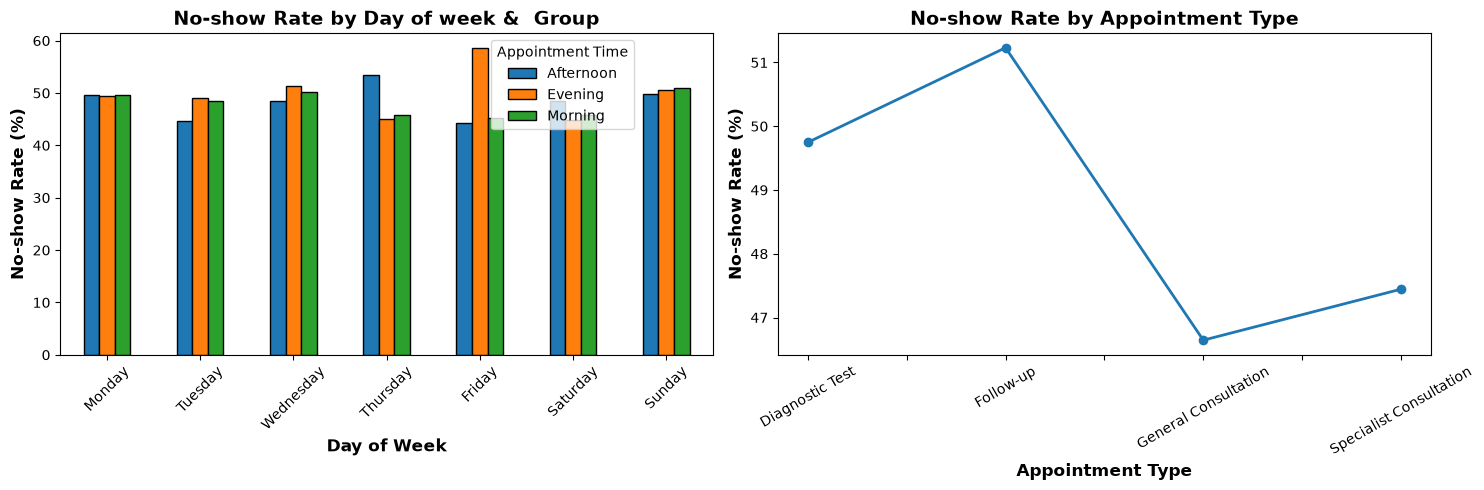

In [21]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

#-----------------------------------------------------------------------
# ANALYSIS 1: NO-SHOW RATE BY DAY OF WEEK & TIME
#-----------------------------------------------------------------------
df['appointment_count'] = (df['appointment_outcome'] == 'No-Show').astype(int)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['appointment_day'] = pd.Categorical(df['appointment_day'], 
                                       categories=day_order, 
                                       ordered=True)
contract_payment_churn = df.groupby(['appointment_day', 'appointment_time'])['appointment_count'].mean() * 100
contract_payment_churn = contract_payment_churn.unstack() 
contract_payment_churn.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('No-show Rate by Day of week &  Group', fontsize=14, weight='bold')
axes[0].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
axes[0].set_ylabel('No-show Rate (%)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Appointment Time', bbox_to_anchor=(0.65, 1.0), loc='upper left')
#-----------------------------------------------------------------------
# ANALYSIS 2: NO-SHOW RATE BY APPOINTMENT TYPE
#-----------------------------------------------------------------------
df['appointment_count'] = (df['appointment_outcome'] == 'No-Show').astype(int)
contract_trend = df.groupby('appointment_type')['appointment_count'].mean() * 100
contract_trend.plot(marker='o', linewidth=2, ax=axes[1])
axes[1].set_title('No-show Rate by Appointment Type', fontsize=14, weight='bold')
axes[1].set_xlabel('Appointment Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('No-show Rate (%)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()

3. Booking Details & Appointment History

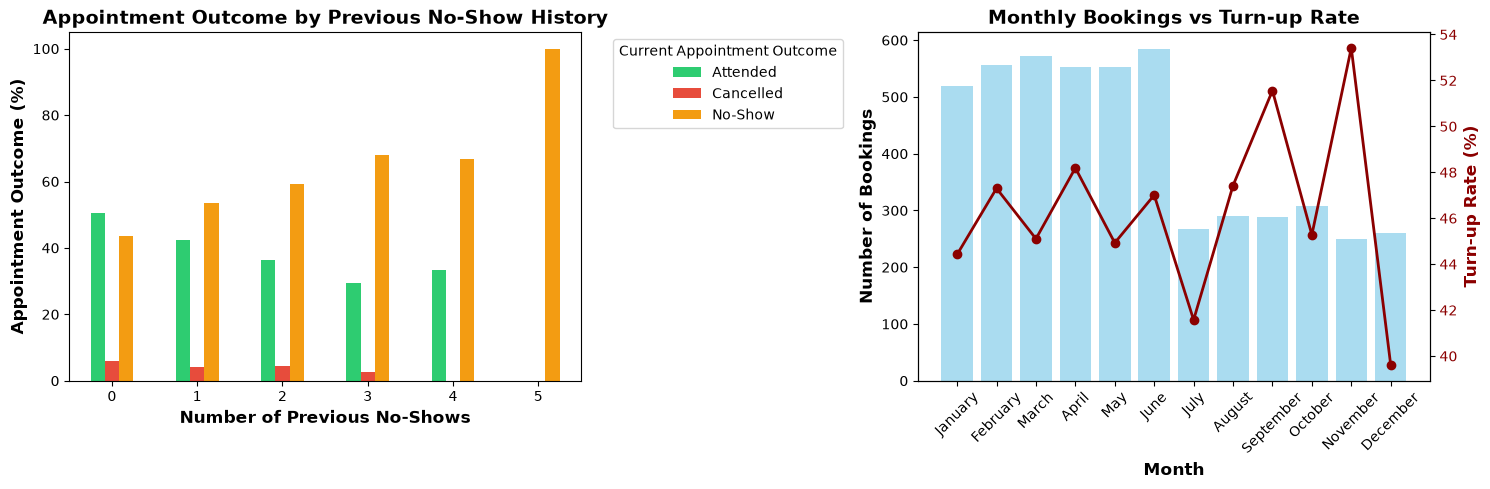

In [ ]:
df['month'] = df['appointment_date'].dt.month_name()
fig, axes = plt.subplots(1,2, figsize=(15,5))
#---------------------------------------
# ANALYSIS 1: PREVIOUS NO-SHOW HISTORY VS CURRENT APPOINTMENT OUTCOME
#---------------------------------------
history_outcome = pd.crosstab(df['previous_no_shows'], df['appointment_outcome'], normalize='index') * 100
history_outcome.plot(kind='bar', ax=axes[0], stacked=False, color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Appointment Outcome by Previous No-Show History', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Previous No-Shows', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Appointment Outcome (%)', fontsize=12, fontweight='bold')
axes[0].legend(title='Current Appointment Outcome', bbox_to_anchor=(1.05, 1.0), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)
#---------------------------------------
# ANALYSIS 2: MONTHLY BOOKINGS VS TURN-UP RATE
#---------------------------------------
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

bookings_per_month = df['month'].value_counts().reindex(month_order)
turnup_per_month = df[df['appointment_outcome'] == 'Attended']['month'].value_counts().reindex(month_order)
turnup_rate = (turnup_per_month / bookings_per_month * 100)


axes[1].bar(bookings_per_month.index, bookings_per_month.values, color='skyblue', alpha=0.7)
axes[1].set_title('Monthly Bookings vs Turn-up Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Bookings', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

ax2 = axes[1].twinx()
ax2.plot(turnup_rate.index, turnup_rate.values, color='darkred', marker='o', linewidth=2)
ax2.set_ylabel('Turn-up Rate (%)', color='darkred', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkred')
plt.tight_layout()

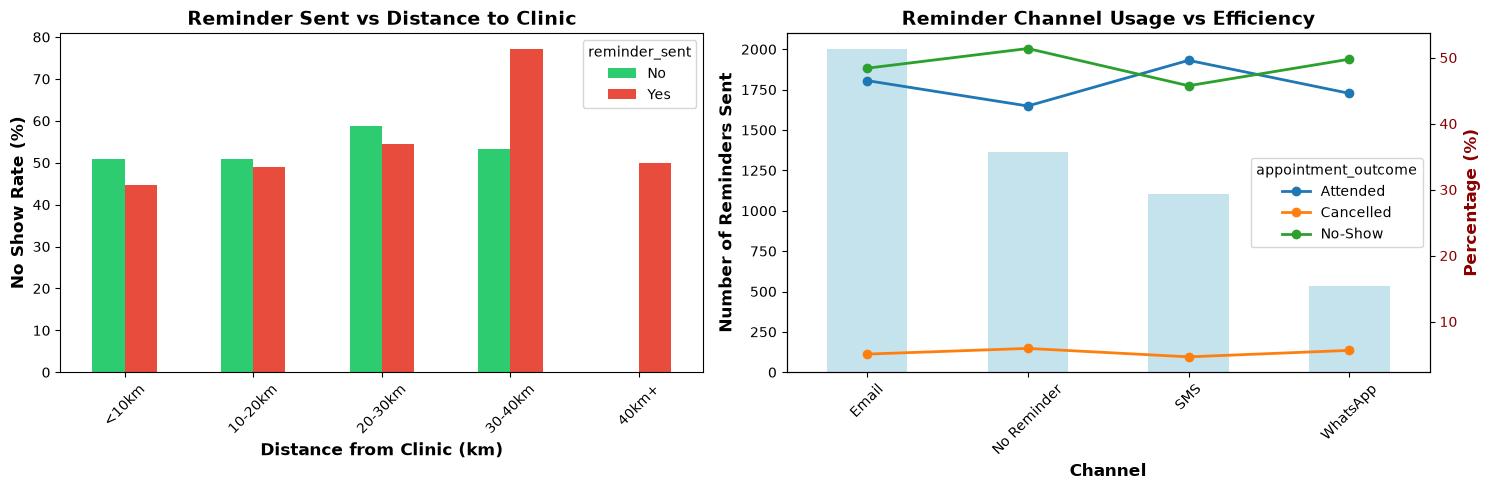

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
#---------------------------------------
# ANALYSIS 1: Reminder vs Clinic Analysis
#---------------------------------------
df['appointment_count'] = (df['appointment_outcome'] == 'No-Show').astype(int)
reminder_outcome = df.groupby(['distance_group', 'reminder_sent'])['appointment_count'].mean() * 100
reminder_outcome = reminder_outcome.unstack()
reminder_outcome.plot(kind='bar', ax=axes[0], stacked=False, color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Reminder Sent vs Distance to Clinic', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Distance from Clinic (km)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('No Show Rate (%)', fontsize=12, fontweight='bold' )
axes[0].tick_params(axis='x', rotation=45)
#---------------------------------------
# ANALYSIS 2: REMINDER CHANNEL USAGE VS EFFICIENCY
#---------------------------------------
channel_counts = df['reminder_channel'].value_counts()
channel_counts.plot(kind='bar', ax=axes[1], color='lightblue', alpha=0.7)
axes[1].set_ylabel('Number of Reminders Sent', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Channel', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

ax1 = axes[1].twinx()
channel_outcome = pd.crosstab(df['reminder_channel'], df['appointment_outcome'], normalize='index') * 100
channel_outcome.plot(kind='line', ax=ax1, marker='o', linewidth=2) 
ax1.set_ylabel('Percentage (%)', color='darkred', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='darkred')

axes[1].set_title('Reminder Channel Usage vs Efficiency', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Channel', fontsize=12, fontweight='bold')

plt.tight_layout()


INSIGHTS
1. Nearly 1 in 2 appointments (48.46%) result in no-shows. This represents a significant loss of revenue and operational inefficiency. The clinic is losing almost as many appointments as it is keeping
2. While Email is the most used reminder channel, SMS achieves the highest attendance conversion
3. Sunday and Friday have the highest no-show rates. Evening appointments show elevated no-show rates across most days.
4. Patients may perceive follow-ups as less urgent or may forget to attend after their initial visit. Diagnostic Tests have the lowest no-show rate.
5. Approximately 1,232 unique patients have missed at least one appointment in the past. Patients with a history of no-shows are at significantly higher risk of future no-shows.
6. Patients living 30-40km away who receive reminders have a 77% no-show rate — 24 percentage points higher than those without reminders. This suggests logistical barriers (transport, traffic, parking) outweigh the effect of reminders.

RECOMMENDATIONS
1. Prioritize SMS reminders as the primary intervention channel to reduce this rate because it has proven to be the most effective channel
2. Shift communication budget from email to SMS reminders, especially for high-risk patient segments.
3. Implement enhanced reminder protocols (e.g., secondary SMS or call) for Sunday and Monday appointments.
4. Offering virtual follow-up consultations to reduce attendance barriers
5. Flag high-risk patients for proactive outreach (e.g., morning-of appointment check-ins or phone calls 48 hours in advance)
6. Offer virtual consultations or transportation assistance for patients living >30km away.
